# Task 3: Cuisine Classification

## Objective

The objective of this task is to develop a machine learning model
that classifies restaurants based on their cuisines.

In this task, the restaurant dataset is preprocessed, categorical
variables are encoded, and the data is divided into training and
testing sets.

A Random Forest Classification algorithm is then trained to predict
the primary cuisine of a restaurant.

The model is evaluated using accuracy, precision, recall, and a
classification report. The performance across different cuisines
is also analyzed.

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


### Explanation

The required Python libraries are imported for data manipulation,
visualization, preprocessing, model building, and evaluation.

- Pandas and NumPy are used for data processing.
- Matplotlib and Seaborn are used for visualization.
- Scikit-learn is used for preprocessing, model training, and evaluation.
- Random Forest is selected as the classification algorithm.


In [6]:
# Load the same dataset used in Task 1 and Task 2

df = pd.read_csv('/content/Dataset.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 3. Dataset Overview

Before building the classification model, we examine the dataset
to understand its structure, columns, and data types.

This helps us identify the features that can be used for predicting
the cuisine of a restaurant.

In [7]:
# Display basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (9551, 21)

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

First 5 Rows:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15 

## 4. Missing Value Analysis

Missing values are checked before building the machine learning model.

Identifying missing data is important because incomplete values can
affect preprocessing and model training.

The cuisine column will also be checked because cuisine is the target
variable for this classification task.

In [8]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

Missing values in each column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Columns with missing values:
Cuisines    9
dtype: int64


## 5. Cuisine Data Analysis

The Cuisines column contains the cuisine information for each
restaurant.

Some restaurants may have more than one cuisine, such as
"North Indian, Chinese".

For classification, we will create a Primary_Cuisine column by
taking the first cuisine listed for each restaurant.

In [9]:
# Check the cuisine column

print("Number of unique cuisine entries:",
      df['Cuisines'].nunique())

print("\nSample cuisine entries:")
display(df['Cuisines'].dropna().head(20))

Number of unique cuisine entries: 1825

Sample cuisine entries:


,Cuisines
0,"French, Japanese, Desserts"
1,Japanese
2,"Seafood, Asian, Filipino, Indian"
3,"Japanese, Sushi"
4,"Japanese, Korean"
5,Chinese
6,"Asian, European"
7,"Seafood, Filipino, Asian, European"
8,"European, Asian, Indian"
9,Filipino


## 6. Create the Primary Cuisine

Some restaurants have multiple cuisines listed in the Cuisines column.

To perform classification, each restaurant needs one target class.

Therefore, the first cuisine listed is selected as the Primary_Cuisine.
Restaurants with missing cuisine information are removed.

In [10]:
# Remove restaurants with missing cuisine information

df = df.dropna(subset=['Cuisines']).copy()

# Create Primary_Cuisine using the first listed cuisine

df['Primary_Cuisine'] = df['Cuisines'].apply(
    lambda x: x.split(',')[0].strip()
)

print("Primary_Cuisine column created successfully!")

print("\nSample results:")
display(df[['Cuisines', 'Primary_Cuisine']].head(15))

Primary_Cuisine column created successfully!

Sample results:


,Cuisines,Primary_Cuisine
0,"French, Japanese, Desserts",French
1,Japanese,Japanese
2,"Seafood, Asian, Filipino, Indian",Seafood
3,"Japanese, Sushi",Japanese
4,"Japanese, Korean",Japanese
5,Chinese,Chinese
6,"Asian, European",Asian
7,"Seafood, Filipino, Asian, European",Seafood
8,"European, Asian, Indian",European
9,Filipino,Filipino


In [11]:
# Count restaurants for each primary cuisine

cuisine_counts = df['Primary_Cuisine'].value_counts()

print("Top 20 Primary Cuisines:")
display(cuisine_counts.head(20))

Top 20 Primary Cuisines:


,count
Primary_Cuisine,
North Indian,2992
Chinese,855
Fast Food,672
Bakery,621
Cafe,617
American,278
South Indian,262
Mithai,246
Street Food,236


## 7. Cuisine Distribution

The distribution of primary cuisines is visualized to understand
which cuisine categories have the highest number of restaurants.

This analysis is useful because the number of restaurants may differ
significantly between cuisine categories.

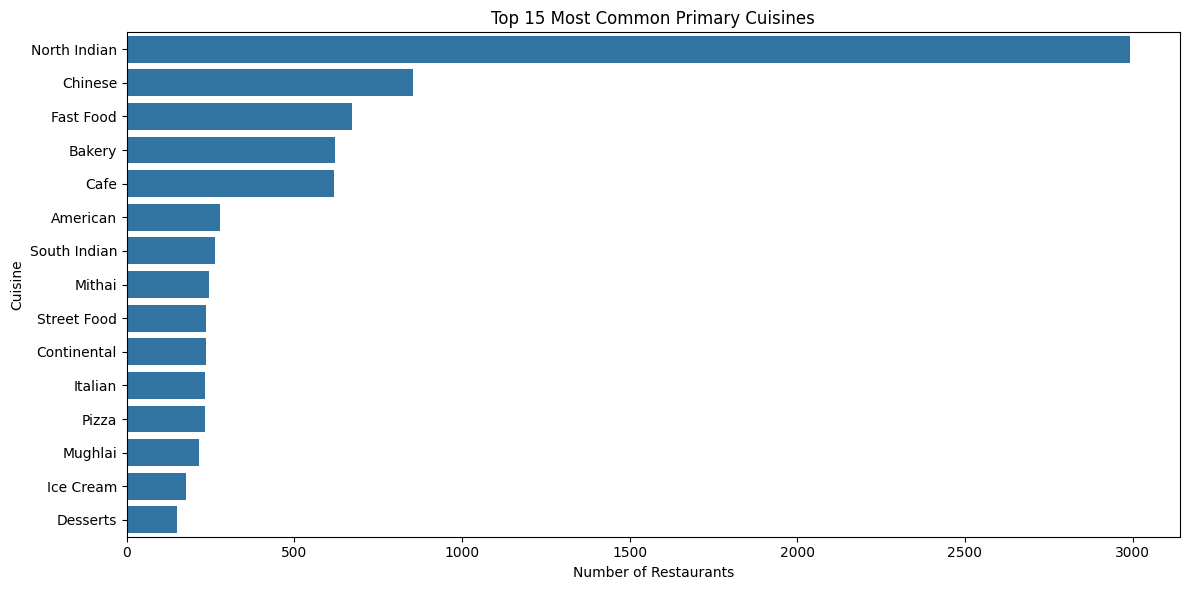

In [12]:
# Get the 15 most common cuisines

top_cuisines = df['Primary_Cuisine'].value_counts().head(15)

# Create the bar chart

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title('Top 15 Most Common Primary Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')

plt.tight_layout()
plt.show()

## 8. Select the Most Common Cuisine Classes

The dataset contains many different cuisine categories, but some
categories have only a small number of restaurants.

To reduce the effect of very small classes, the 10 most common
primary cuisines are selected for classification.

The model will therefore learn to classify restaurants into these
10 cuisine categories.

In [13]:
# Select the 10 most common cuisines

top_10_cuisines = (
    df['Primary_Cuisine']
    .value_counts()
    .head(10)
    .index
)

# Keep only restaurants belonging to these cuisines

df_model = df[
    df['Primary_Cuisine'].isin(top_10_cuisines)
].copy()

print("Selected cuisine classes:")
print(top_10_cuisines.tolist())

print("\nCuisine distribution:")
print(df_model['Primary_Cuisine'].value_counts())

print("\nTotal records for classification:", len(df_model))

Selected cuisine classes:
['North Indian', 'Chinese', 'Fast Food', 'Bakery', 'Cafe', 'American', 'South Indian', 'Mithai', 'Street Food', 'Continental']

Cuisine distribution:
Primary_Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Name: count, dtype: int64

Total records for classification: 7014


## 9. Feature Selection

The restaurant attributes are selected as input features for the
classification model.

The target variable is Primary_Cuisine, which represents the cuisine
that the model needs to predict.

The selected features include restaurant location, cost, booking
options, delivery availability, rating, and number of votes.

In [14]:
# Define input features

features = [
    'City',
    'Average Cost for two',
    'Currency',
    'Has Table booking',
    'Has Online delivery',
    'Price range',
    'Aggregate rating',
    'Votes'
]

# Define target variable

target = 'Primary_Cuisine'

# Create the modelling dataset

model_data = df_model[features + [target]].copy()

print("Selected features:")
print(features)

print("\nTarget variable:")
print(target)

print("\nModel dataset shape:", model_data.shape)

display(model_data.head())

Selected features:
['City', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Price range', 'Aggregate rating', 'Votes']

Target variable:
Primary_Cuisine

Model dataset shape: (7014, 9)


,City,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Votes,Primary_Cuisine
5,Mandaluyong City,1000,Botswana Pula(P),No,No,3,4.4,336,Chinese
11,Pasig City,900,Botswana Pula(P),Yes,No,3,4.2,488,American
15,Santa Rosa,800,Botswana Pula(P),No,No,3,3.6,29,Cafe
18,Taguig City,600,Botswana Pula(P),No,No,2,4.5,118,Cafe
19,Taguig City,1500,Botswana Pula(P),Yes,No,4,4.4,392,Cafe


## 10. Handle Missing Values

Before training the classification model, missing values in the
selected features and target variable are checked.

Rows containing missing values are removed so that the machine
learning model receives complete and valid data.

In [15]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(model_data.isnull().sum())

# Remove rows containing missing values
model_data = model_data.dropna().copy()

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(model_data.isnull().sum())

print("\nFinal dataset shape:", model_data.shape)

Missing values before cleaning:
City                    0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Price range             0
Aggregate rating        0
Votes                   0
Primary_Cuisine         0
dtype: int64

Missing values after cleaning:
City                    0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Price range             0
Aggregate rating        0
Votes                   0
Primary_Cuisine         0
dtype: int64

Final dataset shape: (7014, 9)


## 11. Separate Features and Target

The input features (X) and target variable (y) are separated.

- X contains the restaurant attributes used for prediction.
- y contains the Primary_Cuisine that the model will classify.

In [16]:
X = model_data[features]
y = model_data[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.unique())

Feature shape: (7014, 8)
Target shape: (7014,)

Target classes:
['Chinese' 'American' 'Cafe' 'Fast Food' 'Bakery' 'Continental'
 'South Indian' 'North Indian' 'Street Food' 'Mithai']


## 12. Identify Categorical and Numerical Features

The selected features are divided into two groups:

- Categorical features contain text or category-based values.
- Numerical features contain numeric values.

Categorical features will be encoded before training the model,
while numerical features will be passed directly to the model.

In [17]:
categorical_features = [
    'City',
    'Currency',
    'Has Table booking',
    'Has Online delivery'
]

numerical_features = [
    'Average Cost for two',
    'Price range',
    'Aggregate rating',
    'Votes'
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['City', 'Currency', 'Has Table booking', 'Has Online delivery']

Numerical Features:
['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']


## 13. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used to train the model.
- 20% of the data is used to test the model.
- Stratified splitting is used to maintain a similar distribution
  of cuisine classes in both sets.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (5611, 8)
Testing data shape: (1403, 8)

Training target shape: (5611,)
Testing target shape: (1403,)


## 14. Encode Categorical Features

Machine learning models require numerical input.

The categorical features are converted into numerical values using
One-Hot Encoding.

`handle_unknown='ignore'` ensures that new categories appearing in
the testing data do not cause errors.

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

print("Categorical features will be encoded using One-Hot Encoding.")
print("Preprocessing setup completed successfully!")

Categorical features will be encoded using One-Hot Encoding.
Preprocessing setup completed successfully!


## 15. Select Classification Algorithm

Random Forest Classifier is selected for cuisine classification.

Random Forest combines multiple decision trees to make predictions
and can handle both complex relationships and multiple input features.

In [20]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Classifier created successfully!")
print("Number of trees:", 200)

Random Forest Classifier created successfully!
Number of trees: 200


## 16. Build the Machine Learning Pipeline

A pipeline is created to combine the preprocessing stage and the
Random Forest classification model.

This ensures that categorical encoding and model training are
performed together in a consistent workflow.

In [21]:
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ]
)

print("Machine Learning pipeline created successfully!")

Machine Learning pipeline created successfully!


## 17. Train the Classification Model

The Random Forest model is trained using the training dataset.

The pipeline automatically performs categorical encoding before
training the classifier.

In [22]:
pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## 18. Generate Predictions

The trained Random Forest model is used to predict the cuisine
classes for the unseen testing dataset.

The predicted values are then compared with the actual cuisine
labels to evaluate the model's performance.

In [23]:
y_pred = pipeline.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 20 Actual Values:")
print(y_test.head(20).values)

print("\nFirst 20 Predicted Values:")
print(y_pred[:20])

Predictions generated successfully!

First 20 Actual Values:
['North Indian' 'Chinese' 'Mithai' 'North Indian' 'North Indian'
 'North Indian' 'North Indian' 'North Indian' 'North Indian' 'Chinese'
 'North Indian' 'North Indian' 'North Indian' 'Mithai' 'Cafe'
 'North Indian' 'American' 'Bakery' 'Chinese' 'Chinese']

First 20 Predicted Values:
['Chinese' 'Bakery' 'North Indian' 'South Indian' 'North Indian' 'Cafe'
 'North Indian' 'Chinese' 'North Indian' 'North Indian' 'North Indian'
 'North Indian' 'North Indian' 'Mithai' 'Mithai' 'Chinese' 'Cafe'
 'Chinese' 'North Indian' 'North Indian']


## 19. Model Accuracy

Accuracy measures the percentage of predictions made correctly by
the cuisine classification model.

A higher accuracy indicates that the model correctly classifies a
larger proportion of restaurants in the testing dataset.

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

Accuracy: 0.4098
Accuracy Percentage: 40.98%


## 20. Precision and Recall

Precision measures how many of the restaurants predicted as a
particular cuisine actually belong to that cuisine.

Recall measures how many restaurants belonging to a particular
cuisine were correctly identified by the model.

Weighted averages are used to consider the different sizes of
the cuisine classes.

In [25]:
precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")

Weighted Precision: 0.3617
Weighted Recall: 0.4098


## 21. Classification Report

The classification report provides detailed performance metrics
for each cuisine class.

It includes:

- Precision
- Recall
- F1-score
- Support

This helps us understand how well the model performs for each
individual cuisine.

In [26]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

    American       0.57      0.52      0.54        56
      Bakery       0.20      0.14      0.16       124
        Cafe       0.35      0.28      0.31       123
     Chinese       0.13      0.09      0.11       171
 Continental       0.22      0.13      0.16        47
   Fast Food       0.23      0.16      0.19       135
      Mithai       0.29      0.24      0.26        49
North Indian       0.52      0.71      0.60       599
South Indian       0.12      0.06      0.08        52
 Street Food       0.24      0.21      0.23        47

    accuracy                           0.41      1403
   macro avg       0.29      0.25      0.26      1403
weighted avg       0.36      0.41      0.38      1403



## 22. Confusion Matrix

A confusion matrix is used to visualize the classification results.

It shows the number of correct and incorrect predictions for each
cuisine class.

- Rows represent the actual cuisine.
- Columns represent the predicted cuisine.
- Higher values on the diagonal indicate better classification.

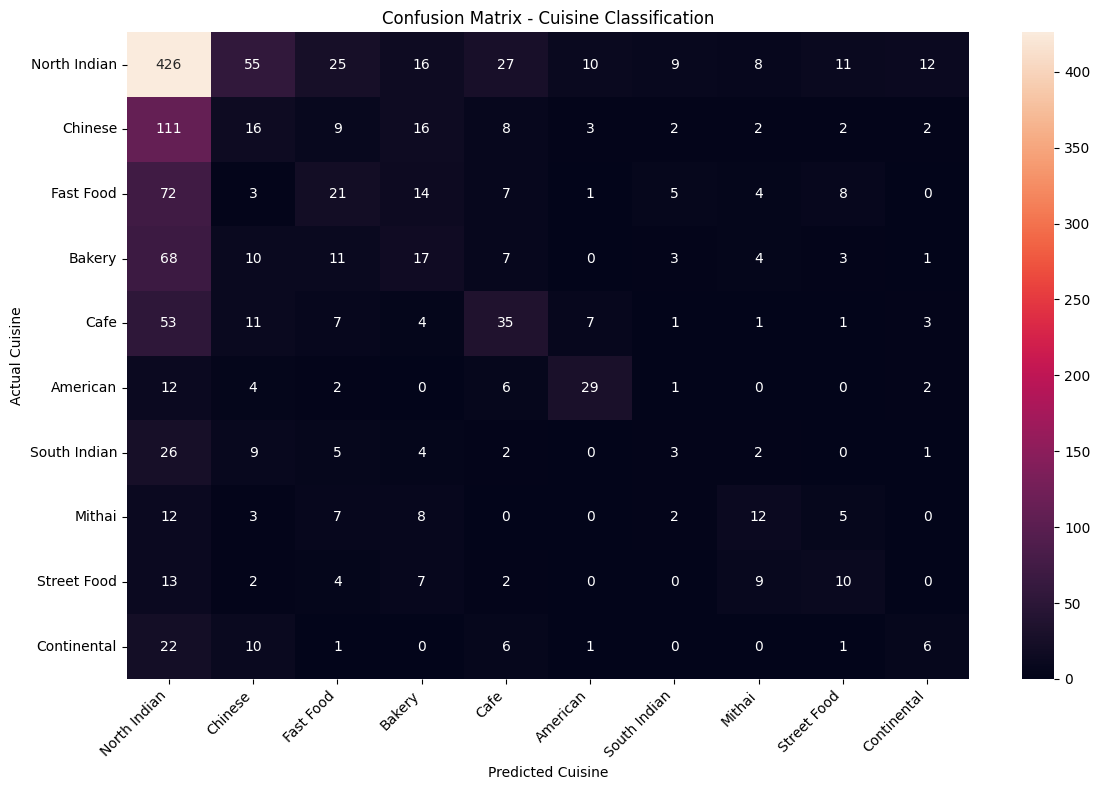

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=top_10_cuisines
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=top_10_cuisines,
    yticklabels=top_10_cuisines
)

plt.title('Confusion Matrix - Cuisine Classification')
plt.xlabel('Predicted Cuisine')
plt.ylabel('Actual Cuisine')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 23. Per-Cuisine Performance Analysis

The classification report is converted into a DataFrame to compare
the performance of the model across different cuisine classes.

Precision, recall, and F1-score are analyzed for each cuisine.

In [28]:
report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

performance = pd.DataFrame(report_dict).T

# Keep only the selected cuisine classes
performance = performance.loc[
    [cuisine for cuisine in top_10_cuisines
     if cuisine in performance.index]
]

print("Performance across cuisines:")

display(
    performance[
        ['precision', 'recall', 'f1-score']
    ]
)

Performance across cuisines:


,precision,recall,f1-score
North Indian,0.522699,0.711185,0.602546
Chinese,0.130081,0.093567,0.108844
Fast Food,0.228261,0.155556,0.185022
Bakery,0.197674,0.137097,0.161905
Cafe,0.350000,0.284553,0.313901
American,0.568627,0.517857,0.542056
South Indian,0.115385,0.057692,0.076923
Mithai,0.285714,0.244898,0.263736
Street Food,0.243902,0.212766,0.227273
Continental,0.222222,0.127660,0.162162


## 24. F1-Score Comparison Across Cuisines

The F1-score combines precision and recall into a single metric.

A bar chart is used to compare the F1-score of the model across
different cuisine classes and identify which cuisines are classified
more accurately.

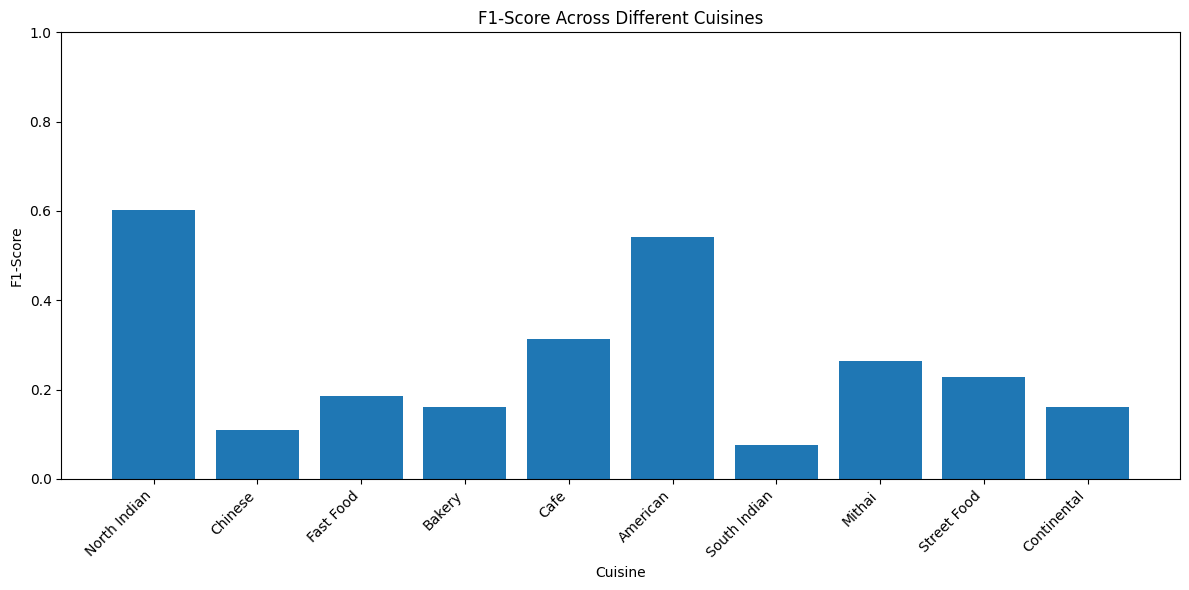

In [29]:
plt.figure(figsize=(12, 6))

plt.bar(
    performance.index,
    performance['f1-score']
)

plt.title('F1-Score Across Different Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 25. Feature Importance Analysis

Random Forest provides feature importance values that show how
strongly different input features contribute to the classification.

The most important features can help us understand which restaurant
attributes are useful for predicting the primary cuisine.

In [30]:
# Get the trained Random Forest model
rf_model = pipeline.named_steps['classifier']

# Get feature names after preprocessing
preprocessor_fitted = pipeline.named_steps['preprocessor']
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance values
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(
    by='Importance',
    ascending=False
)

print("Top 20 Important Features:")

display(feature_importance.head(20))

Top 20 Important Features:


,Feature,Importance
116,remainder__Votes,0.388562
113,remainder__Average Cost for two,0.223172
115,remainder__Aggregate rating,0.211643
114,remainder__Price range,0.034753
64,categorical__City_New Delhi,0.012462
101,categorical__Currency_Indian Rupees(Rs.),0.012003
40,categorical__City_Gurgaon,0.010687
99,categorical__Currency_Dollar($),0.008889
65,categorical__City_Noida,0.008396
112,categorical__Has Online delivery_Yes,0.008066


## 26. Feature Importance Visualization

The feature importance values are visualized using a bar chart.

This helps identify the restaurant attributes that contribute most
to the cuisine classification model.

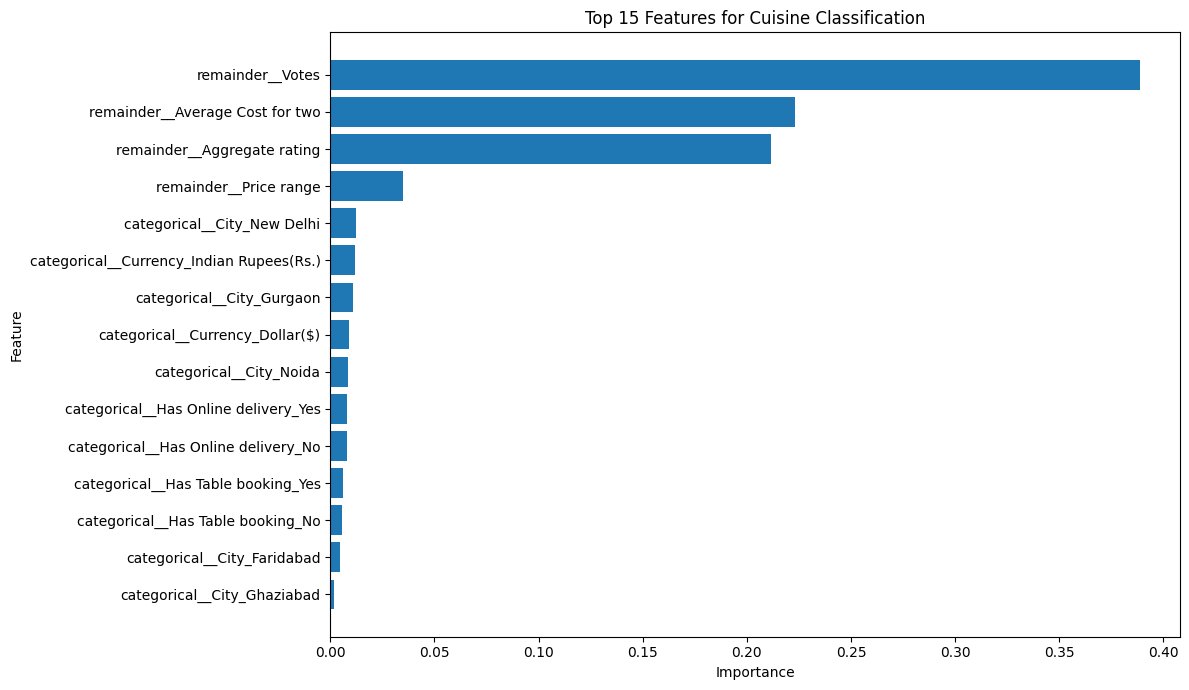

In [31]:
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.title('Top 15 Features for Cuisine Classification')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 27. Actual vs Predicted Cuisine Analysis

The actual cuisine labels from the testing dataset are compared with
the cuisines predicted by the Random Forest model.

This provides a simple view of how accurately the model classifies
individual restaurants.

In [32]:
comparison = pd.DataFrame({
    'Actual Cuisine': y_test.values,
    'Predicted Cuisine': y_pred
})

print("Actual vs Predicted Cuisines:")

display(comparison.head(20))

Actual vs Predicted Cuisines:


,Actual Cuisine,Predicted Cuisine
0,North Indian,Chinese
1,Chinese,Bakery
2,Mithai,North Indian
3,North Indian,South Indian
4,North Indian,North Indian
5,North Indian,Cafe
6,North Indian,North Indian
7,North Indian,Chinese
8,North Indian,North Indian
9,Chinese,North Indian


## 28. Correct and Incorrect Predictions

The actual and predicted cuisine labels are compared to determine
which predictions were correct and which were incorrect.

This helps identify the overall prediction quality and the number
of classification errors made by the model.

In [33]:
comparison['Correct'] = (
    comparison['Actual Cuisine'] ==
    comparison['Predicted Cuisine']
)

correct_predictions = comparison['Correct'].sum()
incorrect_predictions = (~comparison['Correct']).sum()

print("Correct Predictions:", correct_predictions)
print("Incorrect Predictions:", incorrect_predictions)

print(
    f"\nCorrect Prediction Percentage: "
    f"{(correct_predictions / len(comparison)) * 100:.2f}%"
)

print(
    f"Incorrect Prediction Percentage: "
    f"{(incorrect_predictions / len(comparison)) * 100:.2f}%"
)

print("\nSample Incorrect Predictions:")
display(
    comparison[
        comparison['Correct'] == False
    ].head(20)
)

Correct Predictions: 575
Incorrect Predictions: 828

Correct Prediction Percentage: 40.98%
Incorrect Prediction Percentage: 59.02%

Sample Incorrect Predictions:


,Actual Cuisine,Predicted Cuisine,Correct
0,North Indian,Chinese,False
1,Chinese,Bakery,False
2,Mithai,North Indian,False
3,North Indian,South Indian,False
5,North Indian,Cafe,False
7,North Indian,Chinese,False
9,Chinese,North Indian,False
14,Cafe,Mithai,False
15,North Indian,Chinese,False
16,American,Cafe,False


## 29. Final Model Performance Summary

The overall performance of the Random Forest cuisine classification
model is summarized using accuracy, weighted precision, and weighted
recall.

These metrics provide a concise evaluation of how well the model
classifies restaurants into the selected cuisine categories.

In [34]:
# Create a summary of the model performance
metrics_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Weighted Precision',
        'Weighted Recall'
    ],
    'Score': [
        accuracy,
        precision,
        recall
    ]
})

display(metrics_summary)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")

,Metric,Score
0,Accuracy,0.409836
1,Weighted Precision,0.361703
2,Weighted Recall,0.409836


Accuracy: 40.98%
Weighted Precision: 0.3617
Weighted Recall: 0.4098


## 30. Conclusion

In this task, a Random Forest classification model was developed to
classify restaurants based on their primary cuisine.

The dataset was preprocessed by handling missing values, selecting
relevant features, and applying One-Hot Encoding to categorical
variables.

The data was divided into training and testing sets, and the Random
Forest model was trained on the training data.

The model was evaluated using accuracy, precision, recall,
classification report, and confusion matrix.

### Challenges and Potential Biases

- The dataset contains restaurants with multiple cuisines.
  Therefore, the first listed cuisine was selected as the
  Primary_Cuisine for classification.
- Only the top 10 cuisine classes were selected for modelling.
- Cuisine classes may have different numbers of restaurants,
  which can affect model performance.
- Some cuisines may have similar restaurant characteristics,
  making them difficult to distinguish.
- The available restaurant features may not contain enough
  information to perfectly identify a cuisine.

Overall, the model demonstrates how machine learning can be applied
to classify restaurants into different cuisine categories using
restaurant-related attributes.

print("========== TASK 3 FINAL RESULTS ==========")
print(f"Accuracy          : {accuracy * 100:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall   : {recall:.4f}")
print("==========================================")